In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 5")

## Section 1 : Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

In [5]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

MODEL_COLORS = {
    'Logistic Regression': '#3498DB',
    'Decision Tree':       '#E67E22',
    'Random Forest':       '#2ECC71',
    'SVC':                 '#9B59B6'
}
print('Libraries loaded ')

Libraries loaded 


## SEction 2 : Load Data/Models

In [6]:
# Load saved models and test data
model_files = {
    'Logistic Regression': 'models/logistic_regression.pkl',
    'Decision Tree':       'models/decision_tree.pkl',
    'Random Forest':       'models/random_forest.pkl',
    'SVC':                 'models/svc.pkl'
}

In [8]:
trained_models = {name: joblib.load(path) for name, path in model_files.items()}
scaler         = joblib.load('models/scaler.pkl')
feature_names  = joblib.load('models/feature_names.pkl')
X_test         = np.load('models/X_test.npy',        allow_pickle=True)
X_test_scaled  = np.load('models/X_test_scaled.npy', allow_pickle=True)
y_test         = np.load('models/y_test.npy',         allow_pickle=True)

In [9]:
# ── Flatten in case they were saved as object arrays ──────────────
X_test        = X_test.astype(float)
X_test_scaled = X_test_scaled.astype(float)
y_test        = y_test.astype(int)

In [10]:
print("X_test shape       :", X_test.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_test shape       :", y_test.shape)
print("y_test unique      :", np.unique(y_test))

X_test shape       : (392, 19)
X_test_scaled shape: (392, 17)
y_test shape       : (392,)
y_test unique      : [0 1]


In [11]:
# Determine which models use scaling
scaled_models = {'Logistic Regression', 'SVC'}

print('All models and test data loaded ')
print(f'Test set size: {len(y_test)} samples')

All models and test data loaded 
Test set size: 392 samples


## Section 3 : Generate Predictions

In [12]:
predictions = {}
probabilities = {}

for name, model in trained_models.items():
    X = X_test_scaled if name in scaled_models else X_test
    predictions[name]   = model.predict(X)
    probabilities[name] = model.predict_proba(X)[:, 1]

print('Predictions generated for all models')

Predictions generated for all models


## Section 4 : Performance Metrics

In [13]:
metrics_rows = []

for name, y_pred in predictions.items():
    metrics_rows.append({
        'Model':      name,
        'Accuracy':   accuracy_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred, zero_division=0),
        'Recall':     recall_score(y_test, y_pred, zero_division=0),
        'F1 Score':   f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':    auc(*roc_curve(y_test, probabilities[name])[:2])
    })

In [14]:
metrics_df = pd.DataFrame(metrics_rows).round(4)
metrics_df = metrics_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

# Highlight best per column
print('=== Comprehensive Model Metrics ===')
display(metrics_df.style
        .highlight_max(subset=['Accuracy','Precision','Recall','F1 Score','ROC-AUC'],
                       color='#d4edda')
        .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1 Score','ROC-AUC']))

=== Comprehensive Model Metrics ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.8776,0.9805,0.7704,0.8629,0.8656
1,Random Forest,0.8342,0.9712,0.6888,0.8060,0.8793
2,Logistic Regression,0.8291,0.9708,0.6786,0.7988,0.8766
3,SVC,0.8240,1.0000,0.6480,0.7864,0.8781


In [15]:
# Detailed classification report for each model 
for name, y_pred in predictions.items():
    print(f'\n{"=" * 50}')
    print(f'  {name}')
    print(f'{"=" * 50}')
    print(classification_report(y_test, y_pred, target_names=['No Osteoporosis', 'Osteoporosis']))


  Logistic Regression
                 precision    recall  f1-score   support

No Osteoporosis       0.75      0.98      0.85       196
   Osteoporosis       0.97      0.68      0.80       196

       accuracy                           0.83       392
      macro avg       0.86      0.83      0.83       392
   weighted avg       0.86      0.83      0.83       392


  Decision Tree
                 precision    recall  f1-score   support

No Osteoporosis       0.81      0.98      0.89       196
   Osteoporosis       0.98      0.77      0.86       196

       accuracy                           0.88       392
      macro avg       0.90      0.88      0.88       392
   weighted avg       0.90      0.88      0.88       392


  Random Forest
                 precision    recall  f1-score   support

No Osteoporosis       0.76      0.98      0.86       196
   Osteoporosis       0.97      0.69      0.81       196

       accuracy                           0.83       392
      macro avg       0

## Section 5 : Confusion matrix

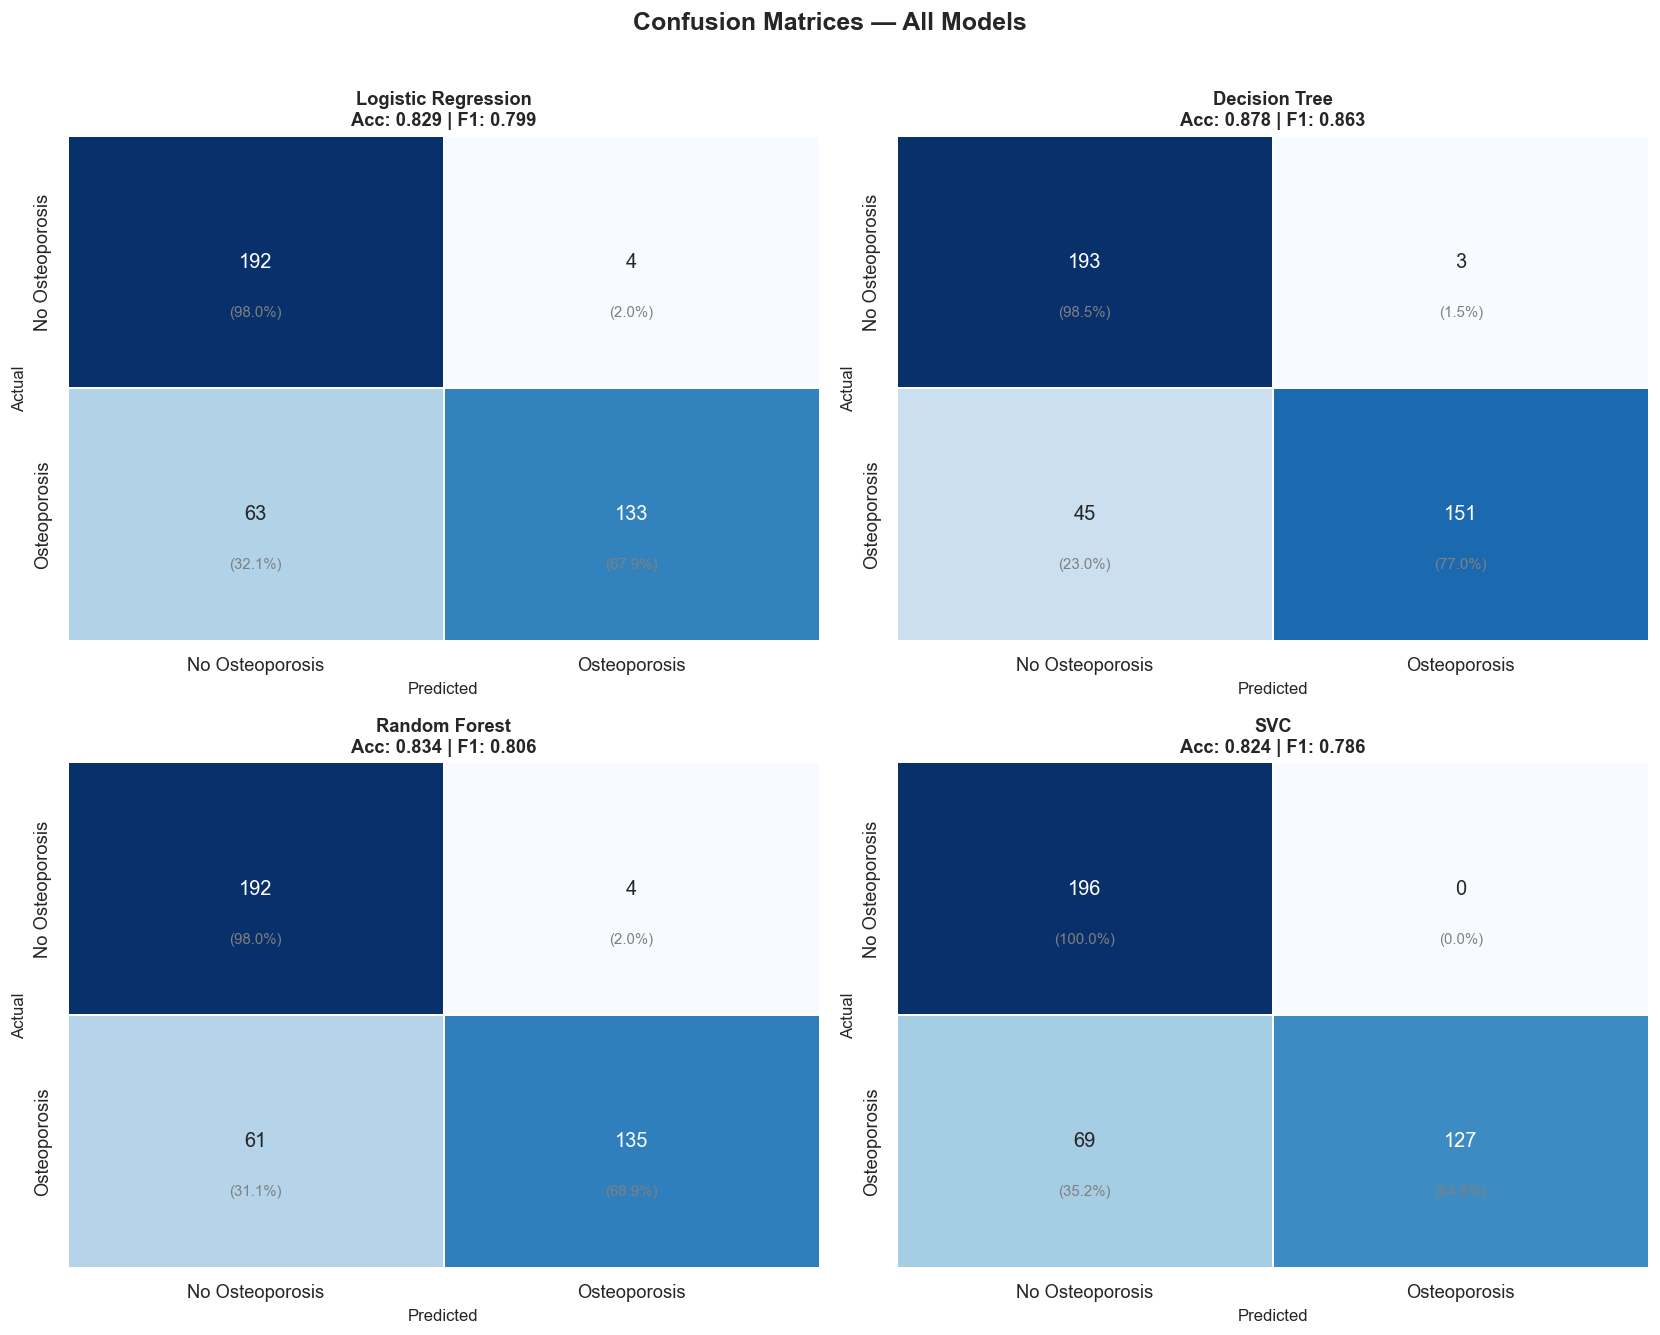

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
labels = ['No Osteoporosis', 'Osteoporosis']

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalized

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=labels, yticklabels=labels,
                linewidths=1, linecolor='white',
                cbar=False)

    # Add % annotations
    for row in range(2):
        for col in range(2):
            axes[i].text(col + 0.5, row + 0.7, f'({cm_norm[row,col]*100:.1f}%)',
                         ha='center', va='center', fontsize=9, color='gray')

    axes[i].set_title(f'{name}\nAcc: {accuracy_score(y_test,y_pred):.3f} | F1: {f1_score(y_test,y_pred):.3f}',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=10)
    axes[i].set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('plot/10_confusion_matrix.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Section 6 : ROC-AUC curves

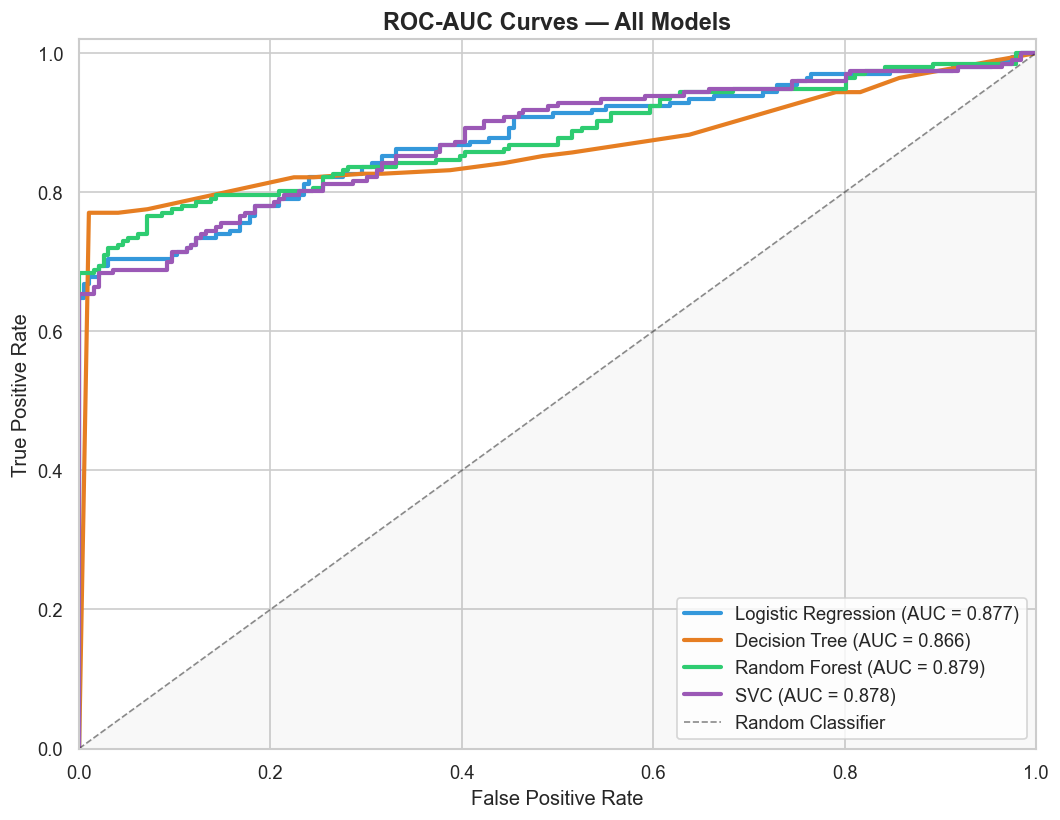

In [17]:
fig, ax = plt.subplots(figsize=(9, 7))

for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2.5, color=MODEL_COLORS[name],
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.savefig('plot/12_ROC_AUC.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Section 7 : Precision Recalls

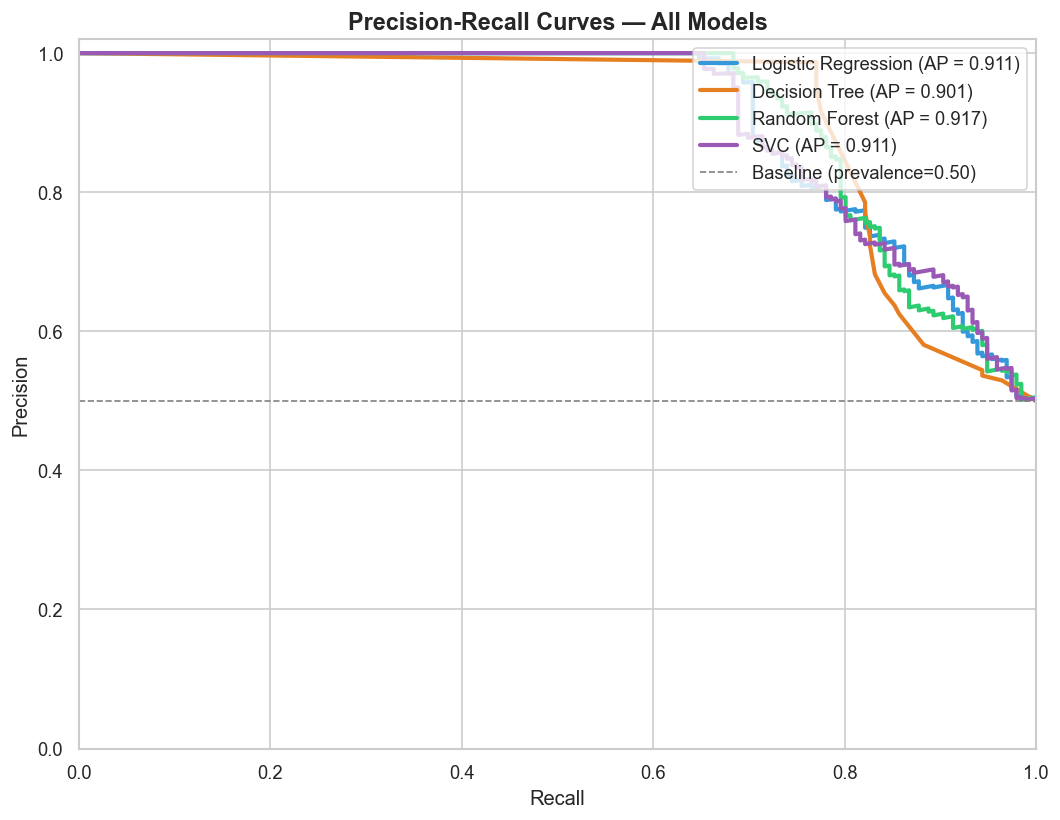

In [19]:
fig, ax = plt.subplots(figsize=(9, 7))
baseline = y_test.mean()

for name, prob in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(recall, precision, linewidth=2.5, color=MODEL_COLORS[name],
            label=f'{name} (AP = {ap:.3f})')

ax.axhline(baseline, color='gray', linestyle='--', linewidth=1,
           label=f'Baseline (prevalence={baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.savefig('plot/13_Precision.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Section 8 : Comparitive Analysis Dashboard

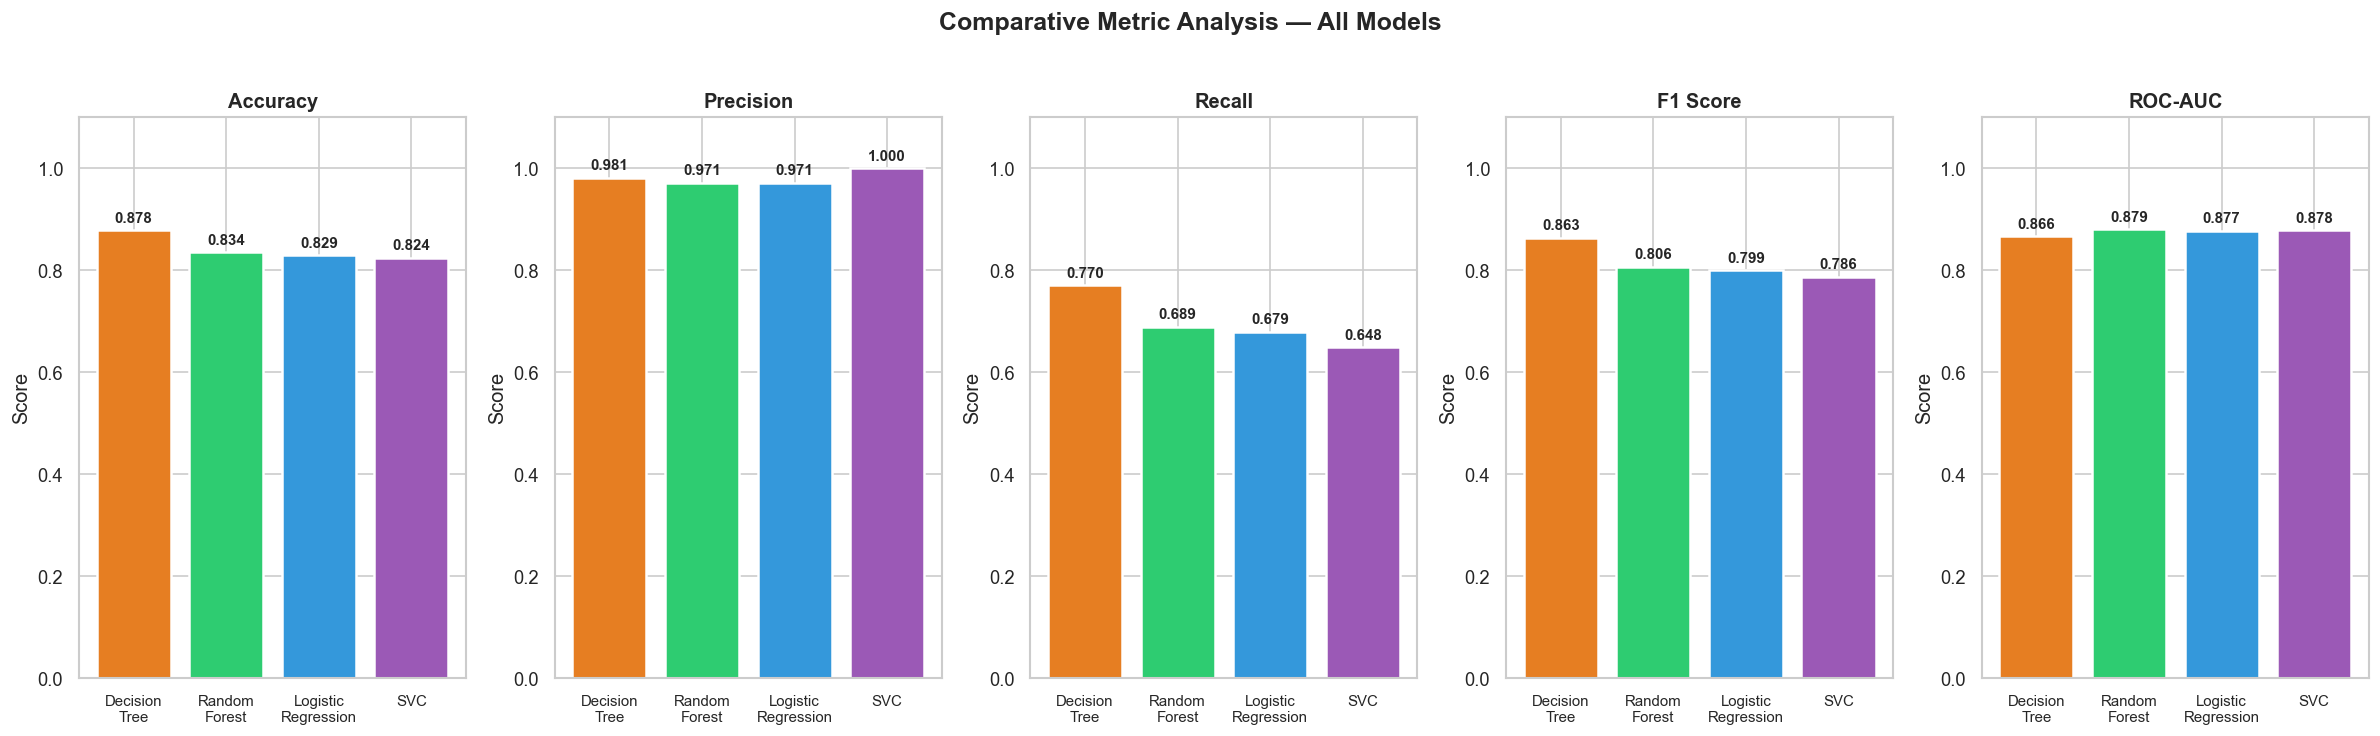

In [21]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

fig, axes = plt.subplots(1, len(metric_cols), figsize=(20, 6))

for i, metric in enumerate(metric_cols):
    vals   = metrics_df[metric].values
    models = metrics_df['Model'].values
    colors = [MODEL_COLORS[m] for m in models]

    bars = axes[i].bar(range(len(models)), vals, color=colors, edgecolor='white', linewidth=1.5)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_xticks(range(len(models)))
    axes[i].set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=9)
    axes[i].set_ylim(0, 1.1)
    axes[i].set_ylabel('Score')

    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Comparative Metric Analysis — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('plot/11_comparitive_analysis_dashboard.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

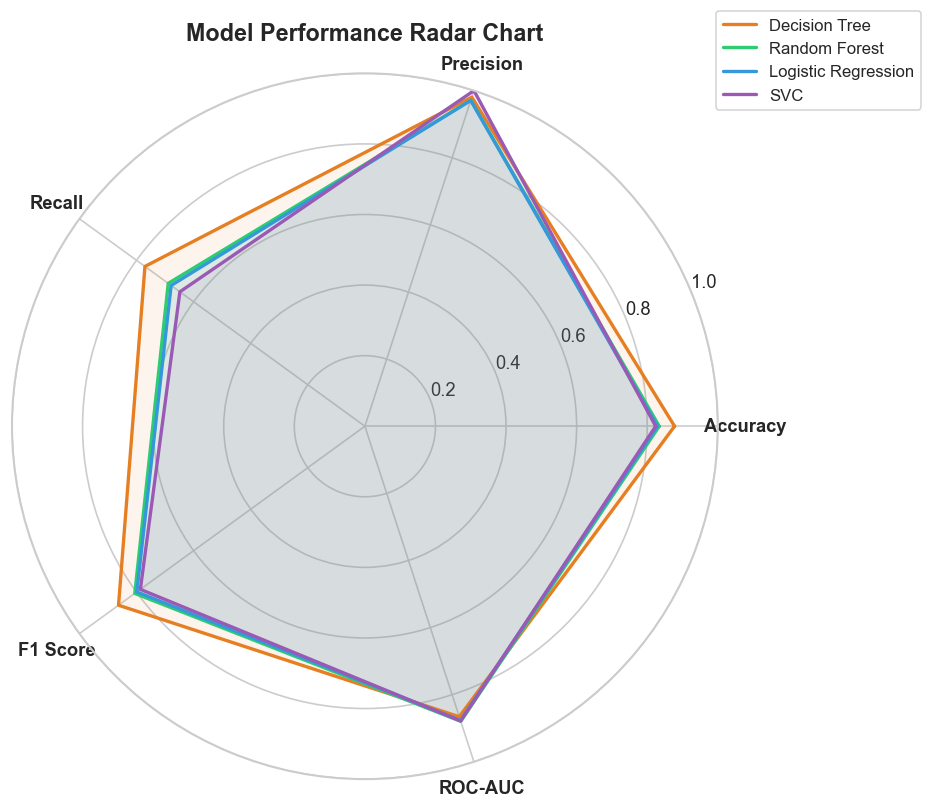

In [22]:
# Radar Chart 
from matplotlib.patches import FancyArrowPatch

categories = metric_cols
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for _, row in metrics_df.iterrows():
    values = row[metric_cols].tolist()
    values += values[:1]
    color  = MODEL_COLORS[row['Model']]
    ax.plot(angles, values, linewidth=2, color=color, label=row['Model'])
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.savefig('plot/14_radar_chart.png', bbox_inches = 'tight')
plt.tight_layout()
plt.show()

## Section 9 : Best Model Threshold Anlysis

In [24]:
best_model_name = metrics_df.iloc[0]['Model']
best_probs = probabilities[best_model_name]

thresholds_range = np.arange(0.1, 0.9, 0.05)
thresh_results = []

In [25]:
for thresh in thresholds_range:
    preds = (best_probs >= thresh).astype(int)
    thresh_results.append({
        'Threshold': thresh,
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall':    recall_score(y_test, preds, zero_division=0),
        'F1':        f1_score(y_test, preds, zero_division=0)
    })

thresh_df = pd.DataFrame(thresh_results)

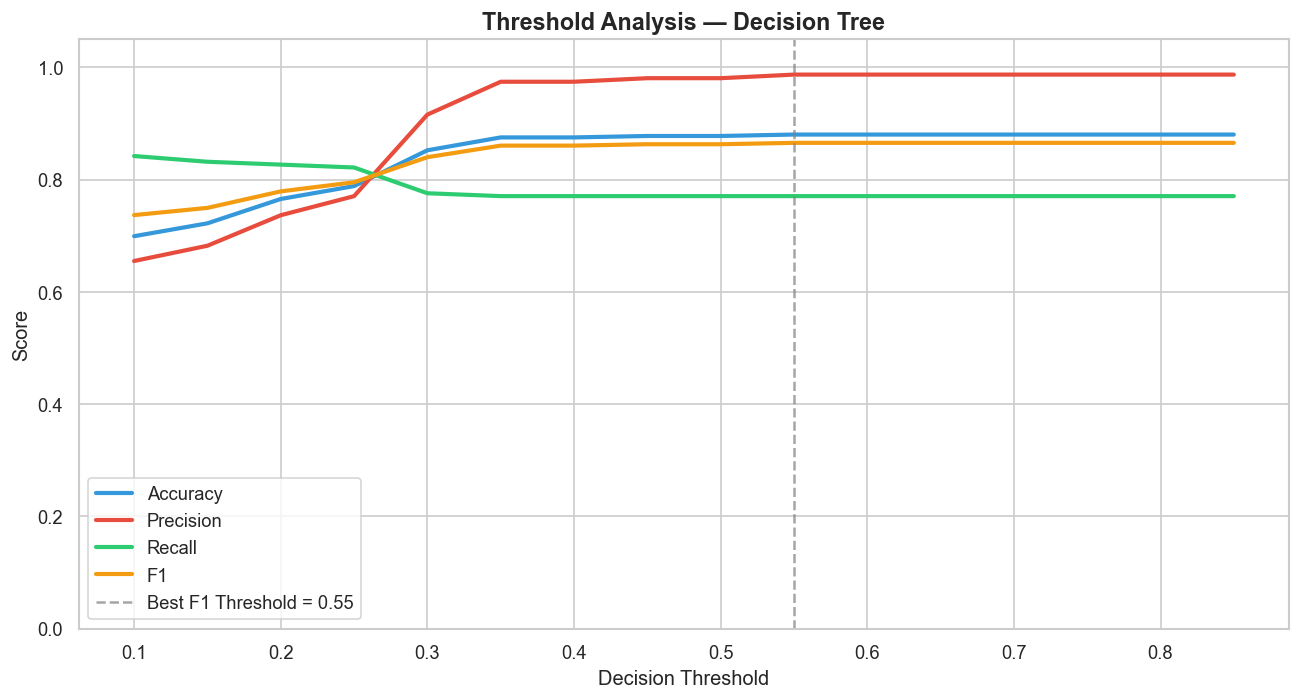

Optimal Threshold: 0.55
At this threshold: {'Threshold': 0.5500000000000002, 'Accuracy': 0.8801020408163265, 'Precision': 0.9869281045751634, 'Recall': 0.7704081632653061, 'F1': 0.8653295128939829}


In [27]:
fig, ax = plt.subplots(figsize=(11, 6))
for metric, color in zip(['Accuracy', 'Precision', 'Recall', 'F1'],
                          ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']):
    ax.plot(thresh_df['Threshold'], thresh_df[metric], linewidth=2.5,
            label=metric, color=color)

best_thresh_idx = thresh_df['F1'].idxmax()
best_thresh     = thresh_df.loc[best_thresh_idx, 'Threshold']
ax.axvline(best_thresh, color='gray', linestyle='--', alpha=0.7,
           label=f'Best F1 Threshold = {best_thresh:.2f}')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Analysis — {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
plt.savefig('plot/15_Threshold_analysis_png', bbox_inches = 'tight')
plt.tight_layout()
plt.show()
print(f'Optimal Threshold: {best_thresh:.2f}')
print(f'At this threshold: {thresh_df.loc[best_thresh_idx].to_dict()}')

## Section 10 : Final Reccommendations

In [28]:
best = metrics_df.iloc[0]

print('=' * 65)
print('   FINAL MODEL RECOMMENDATION')
print('=' * 65)
print(f'\n Recommended Model: {best["Model"]}')
print(f'\n Performance Metrics:')
print(f'   Accuracy:  {best["Accuracy"]:.4f}')
print(f'   Precision: {best["Precision"]:.4f}')
print(f'   Recall:    {best["Recall"]:.4f}')
print(f'   F1 Score:  {best["F1 Score"]:.4f}')
print(f'   ROC-AUC:   {best["ROC-AUC"]:.4f}')
print(f'\n Clinical Relevance:')
print(f'   High Recall = fewer missed osteoporosis cases (critical in healthcare)')
print(f'   Optimal threshold: {best_thresh:.2f}')
print(f'\n All artifacts saved in /models/')
print('\n Evaluation complete — Use the saved model in the web app')

   FINAL MODEL RECOMMENDATION

 Recommended Model: Decision Tree

 Performance Metrics:
   Accuracy:  0.8776
   Precision: 0.9805
   Recall:    0.7704
   F1 Score:  0.8629
   ROC-AUC:   0.8656

 Clinical Relevance:
   High Recall = fewer missed osteoporosis cases (critical in healthcare)
   Optimal threshold: 0.55

 All artifacts saved in /models/

 Evaluation complete — Use the saved model in the web app
